Use the Iris dataset and the SVM code shown in the first class. Define two
new features using the original four features and then calculate the accuracy score of
classification. The SVM classifier must use the new features and none of the original
features for classification.
`

Best hyperparameters: {'svm__C': 1, 'svm__kernel': 'linear'}
Best cross-validated accuracy (training folds): 0.9778
[1 1 1 1 0 1 2 0 0 2 0 2 2 2 2 0 1 2 0 2 2 0 1 0 0 2 1 0 0 0 0 0 1 2 0 1 1
 2 0 1 0 2 2 2 0 2 2 1 0 0 1 1 2 1 2 1 1 2 1 2]
[1 1 1 1 0 1 2 0 0 2 0 2 2 1 2 0 1 2 0 2 2 0 1 0 0 2 1 0 0 0 0 0 1 2 0 1 1
 2 0 1 0 2 2 2 0 2 2 1 0 0 1 1 2 1 2 1 1 2 1 2]
accuracy score : 0.9833333333333333

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        20
  versicolor       1.00      0.95      0.97        20
   virginica       0.95      1.00      0.98        20

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



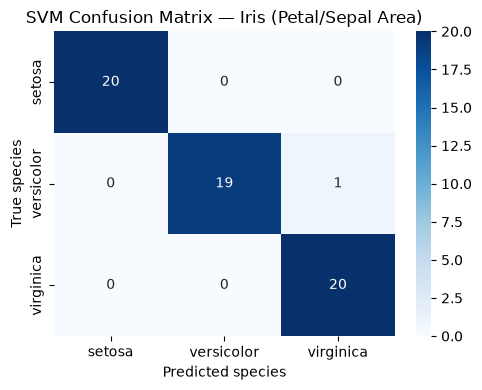


Overall error rate: 0.0167 (1 of 60 misclassified)


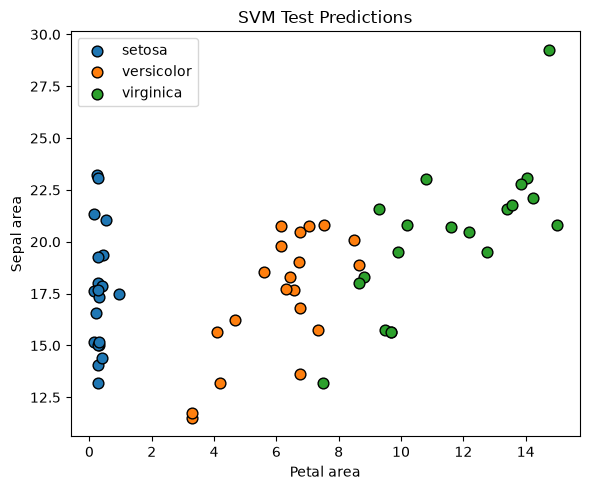

In [72]:
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 123
CV_FOLDS = 5

iris = datasets.load_iris()
X = iris.data[:, :]  # Selecting all features
y = iris.target
target_names = iris.target_names

# New Features
SepalArea = X[:, 0] * X[:, 1]
PetalArea = X[:, 2] * X[:, 3]

Xnew = np.column_stack((PetalArea, SepalArea))

# --- Data splitting ---
X_train, X_test, y_train, y_test = train_test_split(
    Xnew, y,
    test_size=0.40,
    train_size=0.60,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=y)

# --- Data scaling / standardization ---
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", svm.SVC()),
])

# --- Hyperparameter tuning for the SVM, with cross-validation ---
param_grid = [
    {"svm__kernel": ["linear"], "svm__C": [0.01, 0.1, 1, 10, 100]},
    {"svm__kernel": ["rbf"], "svm__C": [0.01, 0.1, 1, 10, 100],
     "svm__gamma": ["scale", "auto", 0.01, 0.1, 1]},
    {"svm__kernel": ["poly"], "svm__degree": [2, 3], "svm__C": [0.1, 1, 10],
     "svm__gamma": ["scale", "auto"]},
]

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print(f"Best hyperparameters: {grid_search.best_params_}")
print(f"Best cross-validated accuracy (training folds): {grid_search.best_score_:.4f}")

clf = grid_search.best_estimator_

# --- Final evaluation on the held-out test set ---
preds = clf.predict(X_test)
acc = accuracy_score(y_test, preds)

print(preds)
print(y_test)
print('accuracy score :', acc)

# --- Error analysis ---
print("\nClassification report:")
print(classification_report(y_test, preds, target_names=target_names))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted species')
plt.ylabel('True species')
plt.title('SVM Confusion Matrix — Iris (Petal/Sepal Area)')
plt.tight_layout()
plt.show()

misclassified_idx = np.where(y_test != preds)[0]
error_rate = len(misclassified_idx) / len(y_test)
print(f"\nOverall error rate: {error_rate:.4f} ({len(misclassified_idx)} of {len(y_test)} misclassified)")

# Visualize correct vs. misclassified points in the 2D engineered-feature space

plt.figure(figsize=(6, 5))
species_colors = sns.color_palette('tab10', n_colors=len(target_names))

for class_idx, species_name in enumerate(target_names):
    mask = y_test == class_idx
    plt.scatter(X_test[mask, 0], X_test[mask, 1],
                color=species_colors[class_idx], label=species_name,
                edgecolor='k', s=60)

plt.xlabel('Petal area')
plt.ylabel('Sepal area')
plt.title('SVM Test Predictions')
plt.legend()
plt.tight_layout()
plt.show()

Classify only the even numbered handwritten digits using MNIST digits dataset
with a k-nearest neighbors classifier. The classifier must not see any odd numbered digit
images as inputs. The classifier must also consider every pixel in the input image to
make its classification decision. Can we use pairplot to visualize this data?. Plot the the
classification results using a heatmap showing digits which were correctly classified and
digits which were not correctly classified. How many 6’s in your test set were correctly
classified?


Even-digit training samples: 29492, classes = [np.uint8(0), np.uint8(2), np.uint8(4), np.uint8(6), np.uint8(8)]
Even-digit test samples: 4926

Running grid search with cross-validation (this can take a few minutes)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best hyperparameters: {'knn__n_neighbors': 3, 'knn__weights': 'distance', 'pca__n_components': 30}
Best cross-validated accuracy (on training folds): 0.9765

Mean CV accuracy by n_neighbors (averaged over other hyperparameters):
param_knn__n_neighbors
3    0.969187
5    0.969813
7    0.968083
9    0.966771
predicted 8 (expected 8)
predicted 2 (expected 2)
predicted 8 (expected 8)
predicted 4 (expected 4)
predicted 4 (expected 4)
predicted 2 (expected 2)
predicted 0 (expected 0)
predicted 0 (expected 0)
predicted 2 (expected 2)
predicted 6 (expected 6)

Test-set accuracy: 0.9770

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       397
 

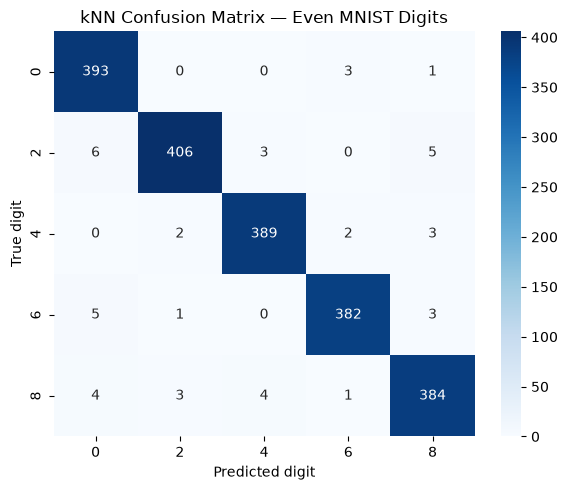

Overall error rate: 0.0230 (46 of 2000 test samples)

Per-class error rate:
  digit 0: 0.0101 (4 of 397 misclassified)
  digit 2: 0.0333 (14 of 420 misclassified)
  digit 4: 0.0177 (7 of 396 misclassified)
  digit 6: 0.0230 (9 of 391 misclassified)
  digit 8: 0.0303 (12 of 396 misclassified)


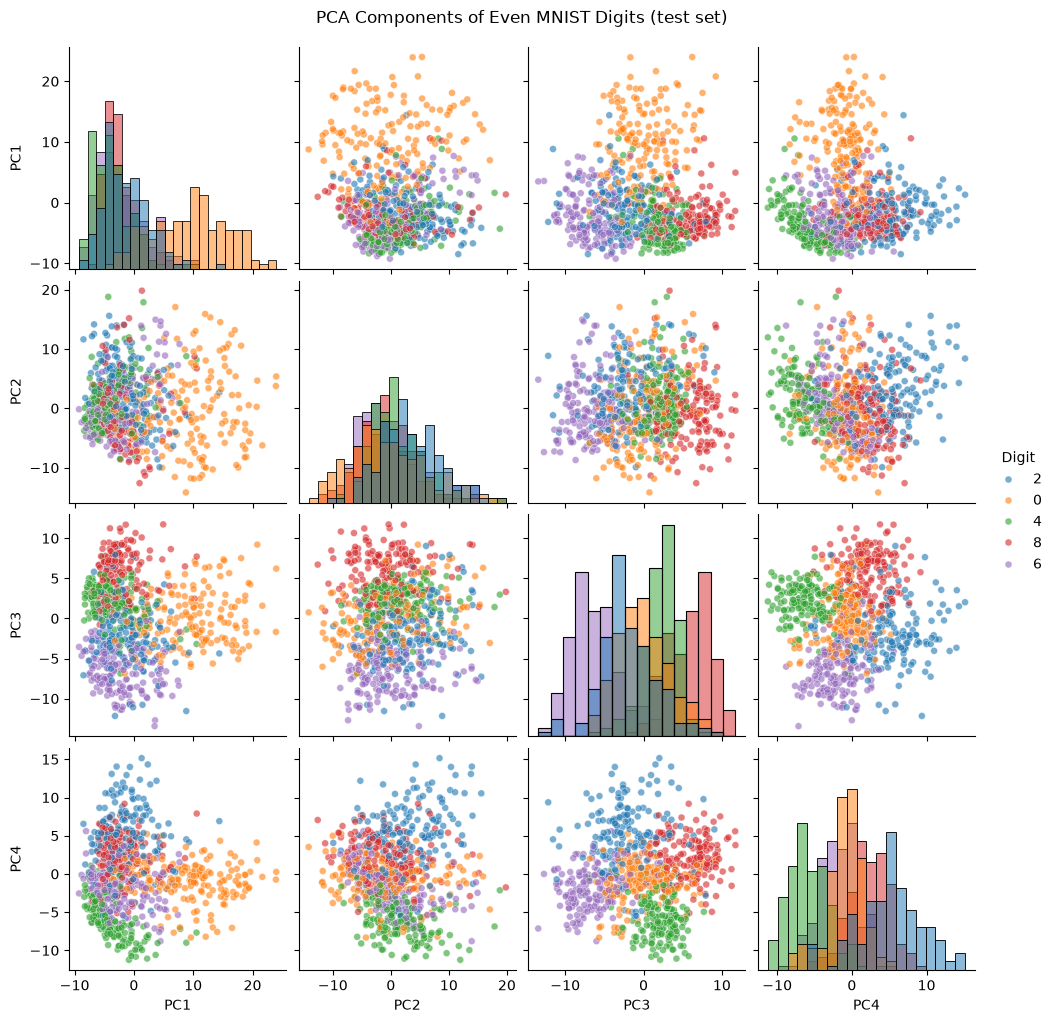

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.datasets import mnist


RANDOM_STATE = 42
CV_FOLDS = 5                # cross-validation folds used during tuning
N_PAIRPLOT_COMPONENTS = 4   # first few PCs shown in the pairplot
TRAIN_SAMPLE_SIZE = 8000    # subsample so kNN + grid search stay fast; None = use all
TEST_SAMPLE_SIZE = 2000
PAIRPLOT_SAMPLE = 800       # points drawn in the pairplot (kept small for legibility)
N_MISCLASSIFIED_TO_SHOW = 10

# Hyperparameter search space: PCA dimensionality and kNN's own hyperparameters.
# Tuning n_components alongside the classifier's hyperparameters matters because
# the right amount of dimensionality reduction depends on how the classifier uses it.
PARAM_GRID = {
    "pca__n_components": [10, 20, 30],
    "knn__n_neighbors": [3, 5, 7, 9],
    "knn__weights": ["uniform", "distance"],
}

# --- Fetch the full MNIST dataset (70,000 samples, 28x28 images) ---
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# --- Filter to even digits only ---
train_mask = y_train % 2 == 0
test_mask = y_test % 2 == 0
x_train, y_train = x_train[train_mask], y_train[train_mask]
x_test, y_test = x_test[test_mask], y_test[test_mask]

print(f"Even-digit training samples: {x_train.shape[0]}, classes = {sorted(np.unique(y_train))}")
print(f"Even-digit test samples: {x_test.shape[0]}")

# Optional subsampling: brute-force kNN plus a hyperparameter grid search
# over the full ~30,000-image training set is very slow. Set the sizes to
# None to use everything.
rng = np.random.default_rng(RANDOM_STATE)
if TRAIN_SAMPLE_SIZE and TRAIN_SAMPLE_SIZE < x_train.shape[0]:
    idx = rng.choice(x_train.shape[0], TRAIN_SAMPLE_SIZE, replace=False)
    x_train, y_train = x_train[idx], y_train[idx]
if TEST_SAMPLE_SIZE and TEST_SAMPLE_SIZE < x_test.shape[0]:
    idx = rng.choice(x_test.shape[0], TEST_SAMPLE_SIZE, replace=False)
    x_test, y_test = x_test[idx], y_test[idx]

# Keep a copy of the un-flattened test images for the error-analysis
# visualization later (we still need x_test itself flattened for the model).
x_test_images = x_test.copy()

# KNeighborsClassifier needs 2D input (n_samples, n_features); flatten each
# 28x28 image into a 784-length vector.
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

# --- Pipeline: standardize -> reduce dimensionality -> classify ---
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=RANDOM_STATE)),
    ("knn", KNeighborsClassifier()),
])

# --- Hyperparameter tuning with cross-validation ---
grid_search = GridSearchCV(
    pipeline,
    PARAM_GRID,
    cv=CV_FOLDS,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
print("\nRunning grid search with cross-validation (this can take a few minutes)...")
grid_search.fit(x_train, y_train)

print(f"\nBest hyperparameters: {grid_search.best_params_}")
print(f"Best cross-validated accuracy (on training folds): {grid_search.best_score_:.4f}")

# A quick look at how sensitive results were to k, averaged over the other params
cv_results = pd.DataFrame(grid_search.cv_results_)
k_summary = cv_results.groupby("param_knn__n_neighbors")["mean_test_score"].mean()
print("\nMean CV accuracy by n_neighbors (averaged over other hyperparameters):")
print(k_summary.to_string())

best_model = grid_search.best_estimator_

# --- Final evaluation on the untouched test set ---
predictions = best_model.predict(x_test)

for i in range(10):
    print('predicted %d (expected %d)' % (predictions[i], y_test[i]))

acc = accuracy_score(y_test, predictions)
print(f"\nTest-set accuracy: {acc:.4f}\n")

class_labels = sorted(np.unique(y_train))
print("Classification report:")
print(classification_report(y_test, predictions, labels=class_labels))

# --- Confusion matrix + heatmap ---
cm = confusion_matrix(y_test, predictions, labels=class_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_labels, yticklabels=class_labels,
)
plt.xlabel('Predicted digit')
plt.ylabel('True digit')
plt.title('kNN Confusion Matrix — Even MNIST Digits')
plt.tight_layout()
plt.show()

# --- Error analysis ---
misclassified_idx = np.where(y_test != predictions)[0]
error_rate = len(misclassified_idx) / len(y_test)
print(f"Overall error rate: {error_rate:.4f} ({len(misclassified_idx)} of {len(y_test)} test samples)")

# Per-class error rate, derived from the confusion matrix
print("\nPer-class error rate:")
for i, label in enumerate(class_labels):
    row_total = cm[i].sum()
    class_error = 1 - (cm[i, i] / row_total) if row_total > 0 else float('nan')
    print(f"  digit {label}: {class_error:.4f} ({row_total - cm[i, i]} of {row_total} misclassified)")

# --- Pairplot of the PCA components used by the best model ---
x_test_pca = best_model[:-1].transform(x_test)
n_dims = min(N_PAIRPLOT_COMPONENTS, x_test_pca.shape[1])
pca_cols = [f'PC{i + 1}' for i in range(n_dims)]

plot_df = pd.DataFrame(x_test_pca[:, :n_dims], columns=pca_cols)
plot_df['Digit'] = y_test.astype(str)
plot_df['Correct'] = np.where(y_test == predictions, 'Correct', 'Misclassified')

if PAIRPLOT_SAMPLE and PAIRPLOT_SAMPLE < len(plot_df):
    plot_df = plot_df.sample(PAIRPLOT_SAMPLE, random_state=RANDOM_STATE)

grid_plot = sns.pairplot(
    plot_df, vars=pca_cols, hue='Digit', palette='tab10',
    diag_kind='hist', plot_kws={'alpha': 0.6, 's': 25},
)
grid_plot.figure.suptitle('PCA Components of Even MNIST Digits (test set)', y=1.02)
plt.show()

Cluster the Iris species by writing your own k-means algorithm using THREE
features (Or modify the algorithm we used in class). Show visualization of the data
using a THREE dimensional scatter plot. Compare the clustering performance of your
k-means algorithm to the sklearn implementation by making plots of the clusters from
your method and Scikit’s implementation by showing the clusters from your methods
and from Scikit’s method. What happens when you vary the number of clusters?

Using matplotlib backend: module://matplotlib_inline.backend_inline


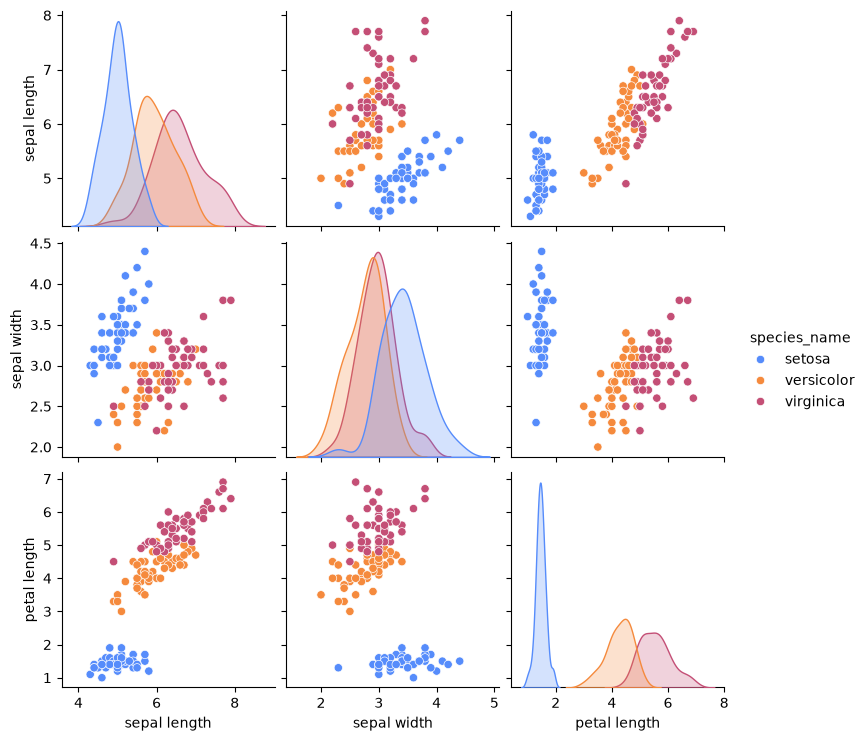

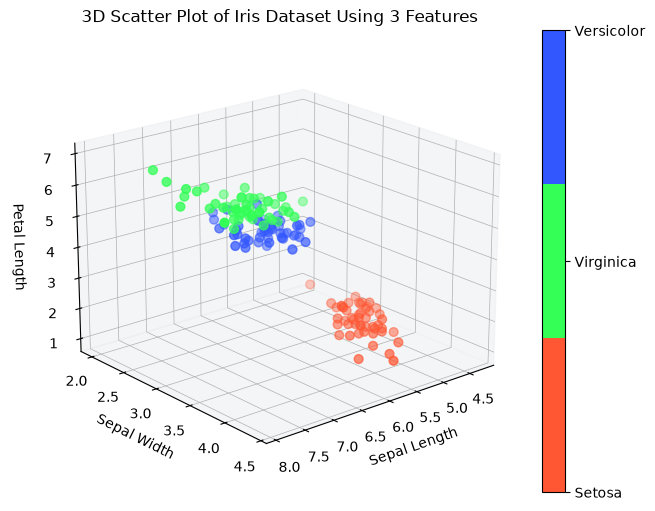

X_train shape : (105, 3)
X_test shape : (45, 3)
X_train shape : (105, 3)
X_test shape : (45, 3)
y_train shape : (105,)
y_test shape : (45,)
predicted_labels: [0 1 0 1 1 2 2 0 2 2 1 2 1 2 0 2 0 0 2 2 2 2 2 0 2 0 1 2 1 1 1 1 0 0 0 0 0
 1 1 2 1 0 0 1 0]
cluster centroids: [[5.82619048 2.72142857 4.35238095]
 [6.77857143 3.02857143 5.62142857]
 [5.04285714 3.43428571 1.48857143]]


Text(0, 0.5, 'silhouette scores')

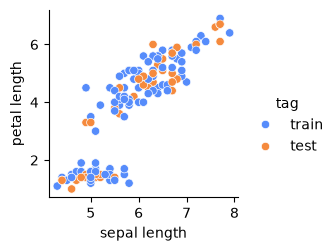

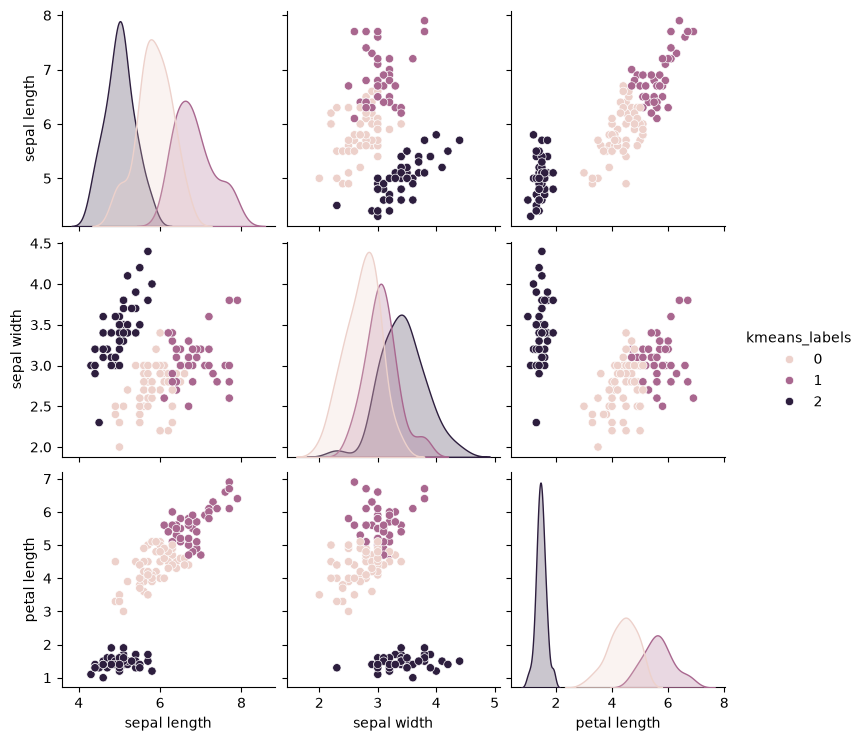

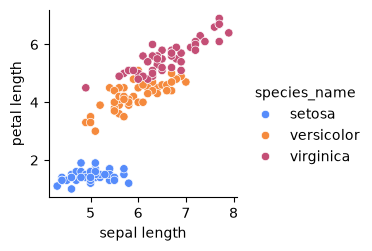

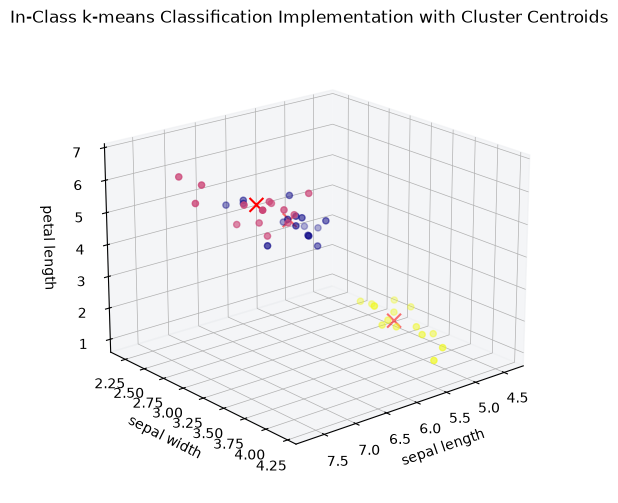

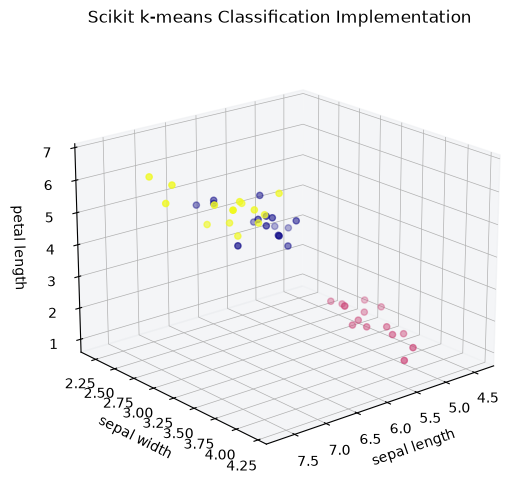

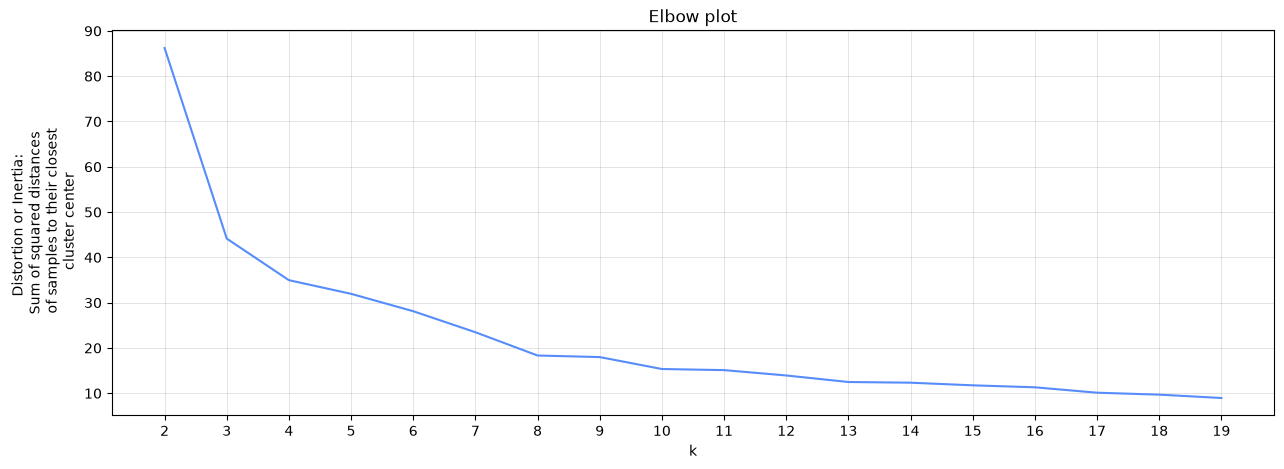

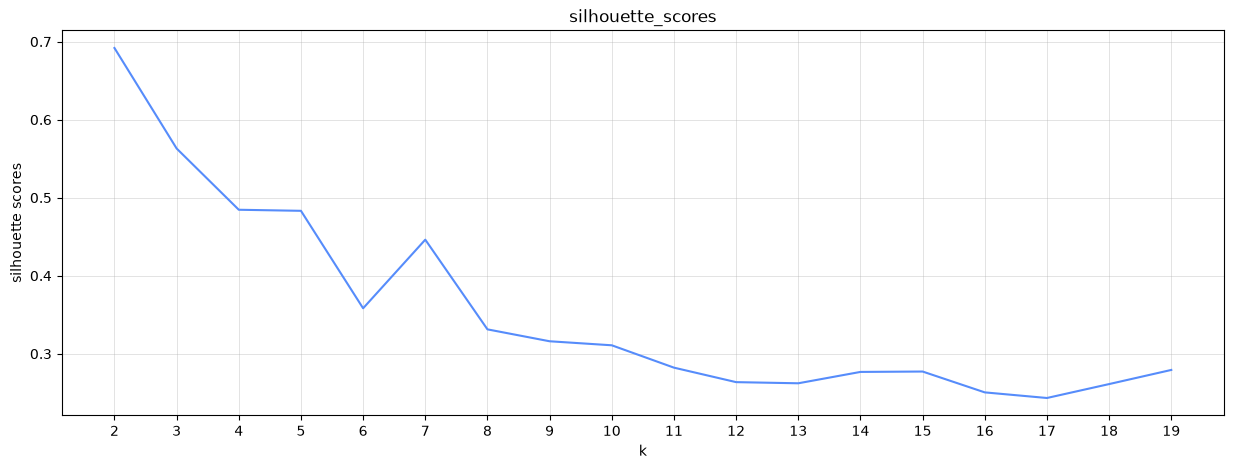

In [74]:
%matplotlib
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

numclusters = 3
### Prepare the data
data = load_iris()  #shift+tab
df = pd.DataFrame()
df['sepal length'] = data['data'][:, 0]
df['sepal width'] = data['data'][:, 1]
df['petal length'] = data['data'][:, 2]
#df['petal width'] = data['data'][:,3]
X = df.to_numpy()  # These are our features
df['target'] = data['target']
named_targets = []

for elm in df['target'].to_list():
    named_targets.append(data.target_names[elm])

df['species_name'] = named_targets
# sns.pairplot(df, hue='target')
sns.pairplot(df.drop(labels=['target'], axis=1), hue='species_name')
# Mapping species names to discrete values so that data can be plotted in a 3D scatterplot
datacolor = np.zeros(len(df['species_name']))
for i in range(datacolor.shape[0]):
    if df['species_name'][i] == 'setosa':
        datacolor[i] = 0
    elif df['species_name'][i] == 'virginica':
        datacolor[i] = 1
    elif df['species_name'][i] == 'versicolor':
        datacolor[i] = 2

custom_colors = ["#FF5733", "#33FF57", "#3357FF"]
cmap_custom = mcolors.ListedColormap(custom_colors)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')

# Plotting the data in a 3D scatterplot
scatter = ax.scatter(df['sepal length'], df['sepal width'], df['petal length'], c=datacolor, cmap=cmap_custom,
                     marker='o', s=40)

# Labels and a color bar
ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
ax.set_title('3D Scatter Plot of Iris Dataset Using 3 Features')
cbar = plt.colorbar(scatter, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(['Setosa', 'Virginica', 'Versicolor'])
ax.view_init(elev=20, azim=50)

# Displaying the plot
plt.show()

# y will not be used because we are doing unsupervised learning
### ideally we should only split X because the data is supposed to be not labeled
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(
    X,
    test_size=0.30,
    train_size=0.70,
    random_state=123,
    shuffle=True)
print('X_train shape :', X_train.shape)
print('X_test shape :', X_test.shape)
### However, since we have labeled iris data we are going to split both X and y and just keep the y seperate. Also split indices to keep track of training and testing data
y = df['target'].to_numpy()
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, range(X.shape[0]),
    test_size=0.30,
    train_size=0.70,
    random_state=123,
    shuffle=True,
    stratify=y)
print('X_train shape :', X_train.shape)
print('X_test shape :', X_test.shape)
print('y_train shape :', y_train.shape)
print('y_test shape :', y_test.shape)
# tag points with train or test labels

tag = []

for _ in range(X.shape[0]):
    if _ in idx_train:
        tag.append('train')
    else:
        tag.append('test')

df['tag'] = tag

sns.pairplot(df.drop(labels=['target'], axis=1), x_vars=['sepal length'],
             y_vars=['petal length'], hue='tag')

## data preparation is complete (on to algorithms)

class KMeans:
    def __init__(self, k):
        self.k = k
        self.cluster_labels = None

    def fit(self, X):
        self.centroids = X[np.random.choice(X.shape[0], self.k, replace=False), :]
        self.cluster_labels = np.arange(self.k)
        while True:
            distances = np.array([np.linalg.norm(X - centroid, axis=1) for centroid in self.centroids])
            self.clusters = np.argmin(distances, axis=0)
            new_centroids = np.array([X[self.clusters == i, :].mean(axis=0) for i in range(self.k)])
            # check convergence
            if np.array_equal(new_centroids, self.centroids):
                break
            else:
                self.centroids = new_centroids

    def predict(self, X):
        distances = np.array([np.linalg.norm(X - centroid, axis=1) for centroid in self.centroids])
        return self.cluster_labels[np.argmin(distances, axis=0)]


model = KMeans(numclusters)
model.fit(X_train)
kmeans_labels = model.predict(X_test)
cluster_coords = model.centroids
print('predicted_labels:', kmeans_labels)
print('cluster centroids:', cluster_coords)
y_train
df['kmeans_labels'] = model.predict(X)
sns.pairplot(df.drop(labels=['target'], axis=1), hue='kmeans_labels')
sns.pairplot(df.drop(labels=['target'], axis=1), x_vars=['sepal length'],
             y_vars=['petal length'], hue='species_name')

df.columns
### locate the cluster centers
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=kmeans_labels, cmap='plasma')
ax.scatter(cluster_coords[:, 0], cluster_coords[:, 1], cluster_coords[:, 2], color='red', marker='x', s=100)
ax.set_xlabel('sepal length')
ax.set_ylabel('sepal width')
ax.set_zlabel('petal length')
ax.set_title('In-Class k-means Classification Implementation with Cluster Centroids')
ax.view_init(elev=20, azim=50)

### let's see how sklearn do
from sklearn.cluster import KMeans

skmodel = KMeans(
    n_clusters=numclusters,
    init='k-means++',
    n_init='auto',
    max_iter=300,
    tol=0.0001,
    verbose=0,
    random_state=None,
    copy_x=True,
    algorithm='lloyd',
)

skmodel.fit(X_train)
skmodel.labels_  # training labels
skmodel.predict(
    X_test)  # predict labels, remember the integers do not make same sense in training and testing for clustering
skmodel_labels = skmodel.predict(X)
skmodel_labels2 = skmodel.predict(X_test)
df['skmodel_labels'] = skmodel_labels
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=skmodel_labels2.tolist(), cmap='plasma')
ax.set_xlabel('sepal length')
ax.set_ylabel('sepal width')
ax.set_zlabel('petal length')
ax.set_title('Scikit k-means Classification Implementation')
ax.view_init(elev=20, azim=50)
# Elbow plot for choosing k if you do not know it
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

distorsions = []
for k in range(2, 20):
    kmeans = KMeans(n_clusters=k, init='k-means++',
                    n_init='auto', )
    kmeans.fit(X_train)
    distorsions.append(kmeans.inertia_)

fig = plt.figure(figsize=(15, 5))
plt.plot(range(2, 20), distorsions)
plt.grid(True)
plt.xticks(ticks=range(2, 20))
plt.title('Elbow plot')
plt.xlabel('k')
plt.ylabel('Distortion or Inertia: \nSum of squared distances\n of samples to their closest\n cluster center')
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(2, 20):
    kmeans = KMeans(n_clusters=k, init='k-means++',
                    n_init='auto', )
    kmeans.fit(X_train)
    silhouette_scores.append(silhouette_score(X_train, kmeans.labels_))

fig = plt.figure(figsize=(15, 5))
plt.plot(range(2, 20), silhouette_scores)
plt.grid(True)
plt.xticks(ticks=range(2, 20))
plt.title('silhouette_scores')
plt.xlabel('k')
plt.ylabel('silhouette scores')